# Numerical error in PyCBC chi-square on LIGO Hanford data

PyCBC's power chi-square (χ²) test checks whether a candidate gravitational-wave signal matches a waveform template across frequency bands. Its CPU implementation can evaluate this statistic at selected times by rotating and summing complex frequency-domain correlation coefficients.

**How much numerical error does this calculation introduce on inputs from a search of real detector data?** This notebook replays one recorded call from a search of LIGO Hanford (H1) strain data. It compares installed PyCBC with two independent double-precision calculations, then uses controlled arithmetic changes to investigate the difference. In the saved run, the largest relative discrepancy among the three selected samples is **+0.172%**.

`complex64` uses 32-bit real and imaginary components; `complex128` uses 64-bit components. The comparisons use the same stored input values throughout.

**Run:** install with `python -m pip install "pycbc==2.11.0" scipy matplotlib jupyterlab`, then **Restart Kernel and Run All**. Tested with [PyCBC 2.11.0](https://pypi.org/project/PyCBC/2.11.0/). The data and arithmetic helper are loaded locally or downloaded with verified hashes. After installing dependencies, a full checkout works offline.

In [1]:
import io
import hashlib
import platform
import warnings
from pathlib import Path
from urllib.request import urlopen

warnings.filterwarnings("ignore", message="Wswiglal-redir-stdio")
import numpy as np
import scipy
from scipy.fft import ifft
import matplotlib.pyplot as plt
import pycbc
from pycbc.types import Array
from pycbc.scheme import CPUScheme
from pycbc.vetoes.chisq import power_chisq_at_points_from_precomputed

print(f"PyCBC {pycbc.__version__}; NumPy {np.__version__}; SciPy {scipy.__version__}")
print(f"Python {platform.python_version()}; {platform.system()} {platform.machine()}")
assert pycbc.__version__ == '2.11.0', 'Select a kernel with the tested PyCBC 2.11.0 release.'

PyCBC 2.11.0; NumPy 2.3.5; SciPy 1.16.3
Python 3.13.9; Darwin arm64


## 1. Load the recorded calculation

The file contains the frequency-domain correlation, unnormalized matched-filter signal-to-noise ratio (SNR), normalization, frequency-bin edges and time-sample indices needed to repeat one χ² call. The source search used public **H1:LOSC-STRAIN**, 32 compressed IMRPhenomD waveform templates, a 2048 Hz sample rate, 512-second segments, a 30 Hz lower cutoff and 16 frequency bins. This replay starts after strain conditioning and matched filtering.

This file, labelled capture 5, was selected because it contained the largest recorded discrepancy among the first six saved calls (11 time samples). We show all three samples in that file and plot sample 656106 in detail. That sample failed the search's reweighted-SNR (NewSNR) threshold. **The selection illustrates an error; it does not measure its typical size or frequency.**

[Capture provenance](https://github.com/xangma/pycbc/blob/7961bd498fa8abbd6f8909cc5ebdff750cbe8fe5/examples/numerics/data/point-input-05.json) · [Search manifest](https://github.com/xangma/pycbc/blob/e8b63f56ea444dca7b5ead91ca3a34da7398e3b5/docs/_static/jax_chisq_numerics/manifest.json).

In [2]:
filename = 'point-input-05.npz'
expected_sha256 = '1b824a1b7887634d8fce7e3a7c356972f417686a2a9924b59413d262592d67ce'
data_url = ('https://raw.githubusercontent.com/xangma/pycbc/'
            '7961bd498fa8abbd6f8909cc5ebdff750cbe8fe5/examples/numerics/data/' + filename)
candidates = [Path('data') / filename, Path('examples/numerics/data') / filename]
local_file = next((p for p in candidates if p.is_file()), None)
if local_file is not None:
    payload = local_file.read_bytes()
else:
    with urlopen(data_url, timeout=60) as response:
        payload = response.read()
assert hashlib.sha256(payload).hexdigest() == expected_sha256
with np.load(io.BytesIO(payload), allow_pickle=False) as saved:
    corr = saved['corr']
    snr = saved['snr']
    norm = float(saved['norm'])
    bins = saved['bins']
    points = saved['indices']

N = len(corr)
p = len(bins) - 1
sample_rate = 2048
segment_seconds = N / sample_rate
widths = np.diff(bins)
assert corr.dtype == np.complex64 and snr.dtype == np.complex64
assert N == 2**20 and p == 16 and np.all(widths > 0)
assert np.all(np.isfinite(corr)) and np.all(points < N)
print(f'Verified {filename}: {len(payload):,} bytes')
print(f'N = {N:,}; segment = {segment_seconds:g} s; frequency spacing = {1/segment_seconds:g} Hz')
print('Selected time samples:', points.tolist())
print('Frequency samples per chi-square bin:', widths.tolist())
print(f'Widest bin: {widths.max():,} samples; {widths.max()-1:,} rotations before its final coefficient')
assert np.array_equal(points, points.astype(np.float32).astype(points.dtype))
print('Float32 index casting changes none of these captured indices.')

Verified point-input-05.npz: 8,390,014 bytes
N = 1,048,576; segment = 512 s; frequency spacing = 0.00195312 Hz
Selected time samples: [484954, 619888, 656106]
Frequency samples per chi-square bin: [9156, 4750, 5023, 5126, 4290, 4627, 4359, 4951, 6051, 6467, 7951, 9583, 12507, 17611, 33168, 373308]
Widest bin: 373,308 samples; 373,307 rotations before its final coefficient
Float32 index casting changes none of these captured indices.


## 2. Compare the CPU result with independent references

At each selected time, let qᵦ be the sum of the correlation coefficients in frequency bin b after applying their time-dependent phase rotations. PyCBC computes

**χ² = (p Σᵦ|qᵦ|² − |snr|²) × norm²**,

where p is the number of bins, `snr` is the saved unnormalized matched-filter sum, and `norm` is its normalization. Hold the SNR-power term and normalization fixed in every comparison.

First run the installed CPU routine with complex64 and complex128 correlations. Then calculate each bin independently using both a complex128 inverse FFT and a direct sum of explicitly evaluated phases. Their agreement checks the reference. Converting the correlation to complex128 preserves its stored values; it only changes the precision used subsequently.

The source search used MKL for its FFTs. Here the correlation is fixed, and the CPU routine being tested performs no FFT.

In [3]:
chisq_cpu = {}
with CPUScheme():
    for dtype in (np.complex64, np.complex128):
        value = power_chisq_at_points_from_precomputed(
            Array(corr.astype(dtype)), snr, norm, bins, points)
        chisq_cpu[np.dtype(dtype).name] = value
        print(f'{np.dtype(dtype).name} input -> {value.dtype} result: {value}')

complex64 input -> float32 result: [33.316555 36.282463 43.05497 ]
complex128 input -> float64 result: [33.32588347 36.33701184 42.98118821]


In [4]:
fft_bin_power = []
fft_power = np.zeros(len(points), dtype=np.float64)
direct_power = np.zeros_like(fft_power)
for lo, hi in zip(bins[:-1], bins[1:]):
    band = np.zeros(N, dtype=np.complex128)
    band[lo:hi] = corr[lo:hi]
    amplitudes = (N * ifft(band, workers=1))[points]
    fft_bin_power.append(np.abs(amplitudes)**2)
    fft_power += fft_bin_power[-1]

    frequencies = np.arange(lo, hi, dtype=np.int64)
    for j, point in enumerate(points):
        cycles = (frequencies * int(point)) % N
        phases = np.exp(2j * np.pi * cycles / N)
        amplitude = np.sum(corr[lo:hi] * phases, dtype=np.complex128)
        direct_power[j] += abs(amplitude)**2

# Preserve the captured complex64 SNR-power calculation in every comparison.
snr_power = (snr.conj() * snr).real
chisq_fft = (p * fft_power - snr_power) * norm**2
chisq_direct = (p * direct_power - snr_power) * norm**2
np.testing.assert_allclose(chisq_direct, chisq_fft, rtol=1e-10, atol=1e-10)
assert np.all(chisq_fft > 0)
print('FFT reference:', chisq_fft)
print('Maximum direct-sum / FFT relative difference:',
      np.max(np.abs(chisq_direct - chisq_fft) / chisq_fft))
reference_cumulative = np.cumsum(np.array(fft_bin_power).T, axis=1)

FFT reference: [33.32594174 36.33709527 42.98097342]
Maximum direct-sum / FFT relative difference: 4.2642019923476617e-16


## 3. Change one arithmetic choice at a time

Changing the input dtype changes several internal calculations together. To distinguish their effects, use a small [NumPy model of the CPU algorithm](https://github.com/xangma/pycbc/blob/4e06fff52a7181f9cb3e8ffffe5b7a3866827a11/examples/numerics/chisq_error_controls.py) with four independently controlled choices:

| Label in the plots | Change from the float64 baseline |
|---|---|
| Truncated π | Replace float64 π with `3.141592653` |
| Float32 phase | Store initial/step phases and repeatedly update them in float32 |
| Float32 terms | Round each operation in the CPU's three-product complex multiplication formula to float32 |
| Float32 sums / powers | Cast terms to float32, add sequentially, form bin powers and add those powers in float32 |

Run all 16 combinations. The baseline uses float64 arithmetic and float64 π; the final χ² expression remains float64 in every model variant. Compiler optimizations and numerical libraries can make the model differ from installed PyCBC, so the table reports that difference separately. In the table, `model all` enables all four changes, `baseline` enables none, and `model−CPU` is the difference from the complex64 CPU result. `c64`/`c128` denote input precision.

The CPU wrapper also converts time indices to the input's real precision. All recorded indices are exactly representable as float32, as checked above, so that conversion contributes zero error here.

In [5]:
from pathlib import Path
from urllib.request import urlopen
import hashlib
import matplotlib.pyplot as plt

# A small, inspectable NumPy model shared by both notebooks; no compiler needed.
helper_name = 'chisq_error_controls.py'
helper_commit = '4e06fff52a7181f9cb3e8ffffe5b7a3866827a11'
helper_sha = 'e582bdbca7184ac59fe96d4058c03d59a4123056a34ce705a397c0a0a1a98954'
local = next((p for p in [Path(helper_name), Path('examples/numerics') / helper_name]
              if p.is_file()), None)
if local is not None:
    source = local.read_bytes()
else:
    url = f'https://raw.githubusercontent.com/xangma/pycbc/{helper_commit}/examples/numerics/{helper_name}'
    with urlopen(url, timeout=60) as response:
        source = response.read()
assert hashlib.sha256(source).hexdigest() == helper_sha
exec(compile(source, helper_name, 'exec'))
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.18, 'lines.linewidth': 1.7})


In [6]:
model_power = controlled_powers(corr, points, bins)
model_chisq = {mask: (p*power[:, -1]-snr_power)*norm**2
               for mask, power in model_power.items()}
np.testing.assert_allclose(model_chisq[0], chisq_fft, rtol=1e-9, atol=1e-9)
# Truncated pi with otherwise double arithmetic also reproduces the compiled
# complex128 control closely; the float32 model is not a bitwise CPU emulator.
np.testing.assert_allclose(model_chisq[1], chisq_cpu['complex128'], rtol=1e-9, atol=1e-9)
assert all(np.all(np.isfinite(value)) for value in model_power.values())
# Fixed denominator: FINAL reference chi-square, not a partial chi-square.
errors = {mask: 100*p*norm**2*(power-reference_cumulative)/chisq_fft[:, None]
          for mask, power in model_power.items()}
effects, interactions = decompose(errors)
highlight = int(np.flatnonzero(points == 656106)[0])
actual_error = {name: 100*(value/chisq_fft-1) for name, value in chisq_cpu.items()}
model_gap = 100*(model_chisq[15]-chisq_cpu['complex64'])/chisq_fft
print('All entries below are signed errors in %, relative to the independent FFT.')
print(f"{'sample':>8} {'CPU c64':>12} {'CPU c128':>12} {'model all':>12} {'baseline':>12} {'model−CPU':>12}")
for j, point in enumerate(points):
    print(f"{point:8d} {actual_error['complex64'][j]:12.6g} {actual_error['complex128'][j]:12.6g} "
          f"{errors[15][j,-1]:12.6g} {errors[0][j,-1]:12.3g} {model_gap[j]:12.3g}")
print(f'\nModel attribution at sample {points[highlight]} (percentage points):')
for bit, label in FACTORS.items():
    print(f'{label:25s} {effects[bit][highlight,-1]:+.8f}')
print(f'{"All interactions":25s} {interactions[highlight,-1]:+.8f}')
print(f'{"Baseline residual":25s} {effects[0][highlight,-1]:+.3g}')
print(f'{"Combined error":25s} {errors[15][highlight,-1]:+.8f}')


All entries below are signed errors in %, relative to the independent FFT.
  sample      CPU c64     CPU c128    model all     baseline    model−CPU
  484954   -0.0281664 -0.000174854   -0.0290199    -1.67e-10    -0.000854
  619888    -0.150348 -0.000229605    -0.149634     1.26e-10     0.000714
  656106     0.172161  0.000499742     0.172096     4.85e-11    -6.49e-05

Model attribution at sample 656106 (percentage points):
Truncated π               +0.00049974
Float32 phase             +0.17355414
Float32 terms             -0.00000119
Float32 sums / powers     -0.00062063
All interactions          -0.00133621
Baseline residual         +4.85e-11
Combined error            +0.17209585


## 4. Show individual effects and their interactions

The upper panel shows the change caused by each arithmetic choice alone, relative to the float64 baseline. The lower panel compares all four choices together with the sum of their individual effects. An **interaction** is the difference arising because changing several arithmetic choices together need not equal adding their separate effects:

**combined error = baseline error + four individual effects + interactions**.

All 16 variants contribute to the interaction calculation; this identity is checked at every bin. The curves accumulate complete frequency bins from left to right. Every value is expressed as a percentage of the **final reference χ²**, using the same denominator throughout; intermediate points are not partial χ² statistics. The signed logarithmic scale makes small positive and negative contributions visible. The diamond marks the installed complex64 CPU result.

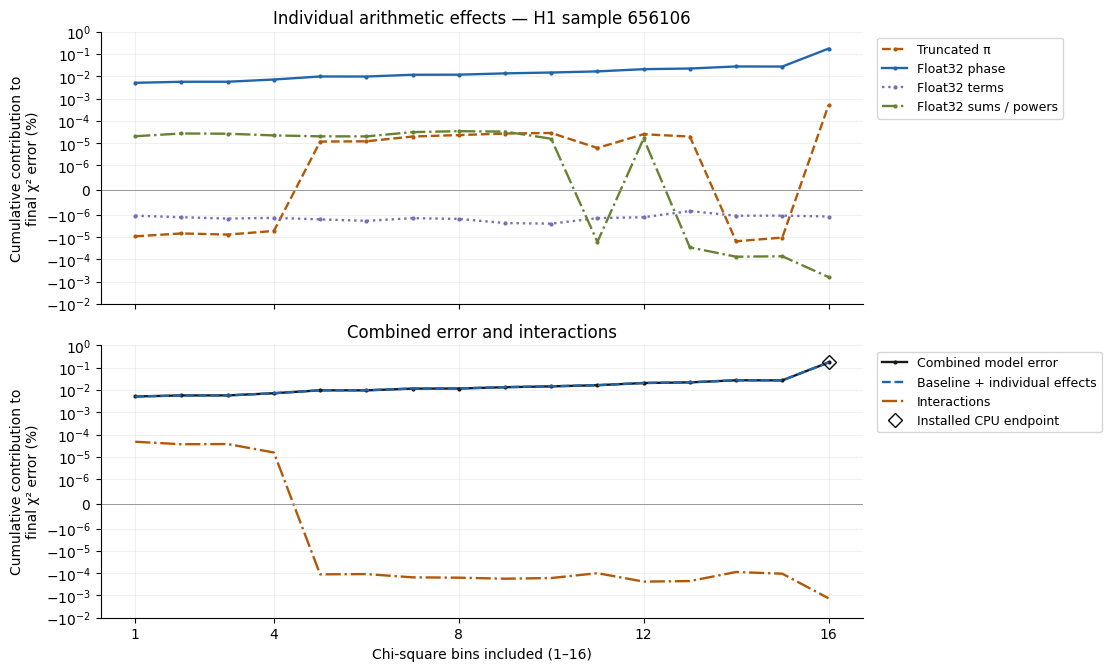

In [7]:
x = np.arange(1, p+1)
fig, axes = plt.subplots(2, 1, figsize=(11, 6.6), sharex=True, layout='constrained')
for bit, label in FACTORS.items():
    axes[0].plot(x, effects[bit][highlight], label=label,
                 color=COLORS[bit], ls=STYLES[bit], marker='.', ms=4)
axes[0].set_title(f'Individual arithmetic effects — H1 sample {points[highlight]}')
axes[0].legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.01, 1))
additive = effects[0] + sum(effects[bit] for bit in FACTORS)
axes[1].plot(x, errors[15][highlight], color='0.1', label='Combined model error', marker='.', ms=4)
axes[1].plot(x, additive[highlight], color='#2166ac', ls='--', label='Baseline + individual effects')
axes[1].plot(x, interactions[highlight], color='#b35806', ls='-.', label='Interactions')
axes[1].plot(p, actual_error['complex64'][highlight], 'D', mfc='none', mec='black', ms=7,
             label='Installed CPU endpoint')
axes[1].set_title('Combined error and interactions')
axes[1].set(xlabel='Chi-square bins included (1–16)', xticks=[1,4,8,12,16])
axes[1].legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.01, 1))
for ax in axes:
    ax.set_yscale('symlog', linthresh=1e-6)
    ax.set_ylim(-0.01, 1)
    ax.set_ylabel('Cumulative contribution to\nfinal χ² error (%)')
    ax.axhline(0, color='0.6', lw=0.7)
plt.show()


**What the results show:** at the plotted sample, float32 phase arithmetic contributes about +0.174 percentage points in the model. The smaller π, multiplication and accumulation effects, together with their interactions, give a combined error of about +0.172%. The float64 baseline agrees closely with both independent references.

The model's difference from compiled PyCBC is reported in the table, so the curves explain controlled arithmetic effects rather than an exact allocation of the executable's error. This selected replay does not establish changes in search sensitivity, candidate ranking or false-alarm rate.

For exact-answer experiments, including a large time-index boundary case, see the [synthetic example](cpu_chisq_precision.ipynb). Sources: [PyCBC 2.11.0 CPU code](https://github.com/gwastro/pycbc/blob/v2.11.0/pycbc/vetoes/chisq_cpu.pyx) · [Technical report](https://github.com/xangma/pycbc/blob/e8b63f56ea444dca7b5ead91ca3a34da7398e3b5/docs/jax_chisq_numerics.rst).